# 01 — Data & Envelope EDA

Explore log returns, next-5-day envelope targets, regime labels, and chronological splits.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _ in range(3):
    if (PROJECT_ROOT / "src_regi").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    raise RuntimeError("Open notebook under Advanced Machine Learning Project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src_regi.config import load_config
from src_regi.data import prepare_data, split_arrays
from src_regi.targets import cumulative_log_price, compute_envelope_targets

In [2]:
cfg = load_config(PROJECT_ROOT / "config_regi.json")
target = cfg["data"]["target_ticker"]
prepared = prepare_data(cfg)
splits = split_arrays(prepared)
print(f"Target: {target} | Features: {prepared.features.shape}")
print(f"Train/val/test ends: {prepared.train_end}, {prepared.val_end}, {len(prepared.features)}")

Target: NVDA | Features: (2257, 19)
Train/val/test ends: 1579, 1917, 2257


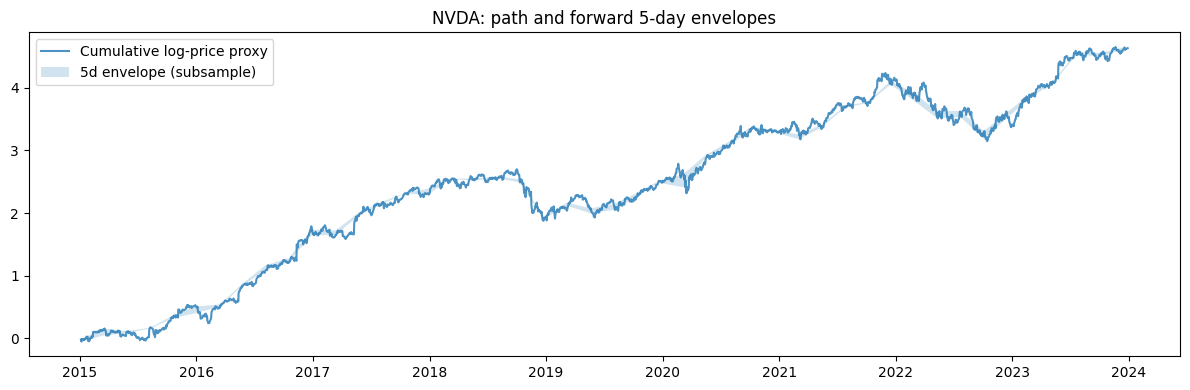

In [3]:
raw = pd.read_csv(PROJECT_ROOT / cfg["data"]["log_returns_path"], parse_dates=["Date"], index_col="Date")
cum = cumulative_log_price(raw[target])
env = compute_envelope_targets(raw, target, horizon=cfg["data"]["forecast_horizon"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cum.index, cum.values, label="Cumulative log-price proxy", alpha=0.8)
sample = env.iloc[::50]
ax.fill_between(sample.index, sample["week_min"], sample["week_max"], alpha=0.2, label="5d envelope (subsample)")
ax.set_title(f"{target}: path and forward 5-day envelopes")
ax.legend()
plt.tight_layout()
plt.show()

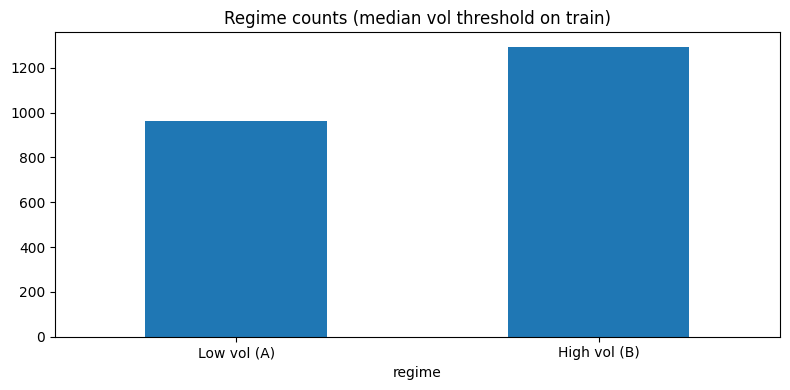

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
prepared.regimes.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_xticklabels(["Low vol (A)", "High vol (B)"], rotation=0)
ax.set_title("Regime counts (median vol threshold on train)")
plt.tight_layout()
plt.show()

In [5]:
for name, sl in splits.items():
    sub = prepared.envelopes.iloc[sl]
    print(f"{name}: n={len(sub)}, mean range={sub['week_range'].mean():.4f}")

train: n=1579, mean range=0.0540
val: n=338, mean range=0.0737
test: n=340, mean range=0.0677
